### **1.import required dependencies**

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import uniform, randint
from dotenv import load_dotenv
import os
from pathlib import Path

from sklearn.model_selection import GroupShuffleSplit,RandomizedSearchCV, StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score,f1_score, classification_report, recall_score

In [3]:
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f"{x:.3f}")
sns.set_theme(style='darkgrid')

In [4]:
load_dotenv()

RANDOM_STATE=os.getenv('RANDOM_STATE')
DATASET_PATH= (os.getenv('PROJECT_ROOT')) / Path(os.getenv('DATA_DIR')) / Path(os.getenv('DATASET_NAME'))
TARGET_COL=os.getenv('TARGET_COL')


### **2.Load Dataset**

In [5]:
df = pd.read_csv(DATASET_PATH)
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.000,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.100,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.600,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.000,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.900,1,3,2,0


### **3.Exploratoty Data Analysis(EDA)**

#### **1.Basic Data Quality Checks**

In [6]:
print(df.shape)
print("-"*70)
print(df.info())
print("-"*70)
print(df.describe())

(1025, 14)
----------------------------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB
None
----------------------------------------------------------------------
           age      sex       cp  trestbps     chol      fbs  restecg

In [7]:
print(df.columns)
print("-"*70)
print(df.nunique())
print("-"*70)
print(df['age'].value_counts())

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='str')
----------------------------------------------------------------------
age          41
sex           2
cp            4
trestbps     49
chol        152
fbs           2
restecg       3
thalach      91
exang         2
oldpeak      40
slope         3
ca            5
thal          4
target        2
dtype: int64
----------------------------------------------------------------------
age
58    68
57    57
54    53
59    46
52    43
51    39
56    39
62    37
60    37
44    36
64    34
63    32
41    32
61    31
67    31
55    30
65    27
53    26
43    26
42    26
45    25
66    25
46    23
48    23
50    21
47    18
49    17
35    15
70    14
39    14
38    12
68    12
71    11
40    11
69     9
34     6
37     6
29     4
76     3
77     3
74     3
Name: count, dtype: int64


#### **2.Missing Value Summary**

In [8]:
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_percent = df.isnull().mean().sort_values(ascending=False)

missing_df = pd.DataFrame({'missing_values': missing_values, 'missing_percent': missing_percent})
print(missing_df)

          missing_values  missing_percent
age                    0            0.000
sex                    0            0.000
cp                     0            0.000
trestbps               0            0.000
chol                   0            0.000
fbs                    0            0.000
restecg                0            0.000
thalach                0            0.000
exang                  0            0.000
oldpeak                0            0.000
slope                  0            0.000
ca                     0            0.000
thal                   0            0.000
target                 0            0.000


#### **3.Duplicates**

In [9]:
duplicate_df=df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_df}")

Number of duplicate rows: 723


#### **4.Data type Validation**

In [10]:
expected_values = {
    "age": "int64",
    "sex": "int64",
    "cp": "int64",
    "trestbps": "int64",
    "chol": "int64",
    "fbs": "int64",
    "restecg": "int64",
    "thalach": "int64",
    "exang": "int64",
    "oldpeak": "float64",
    "slope": "int64",
    "ca": "int64",
    "thal": "int64",
    "target": "int64"
}

for column, expected_dtype in expected_values.items():
    if column in df.columns:
        actual_dtype = df[column].dtype
        if actual_dtype == expected_dtype:
            print(f"Column '{column}' has the expected data type: {expected_dtype}.")
        else:
            print(f"Column '{column}' has an unexpected data type: {actual_dtype} (expected: {expected_dtype}).")
    else:
        print(f"Column '{column}' is missing from the DataFrame.")

Column 'age' has the expected data type: int64.
Column 'sex' has the expected data type: int64.
Column 'cp' has the expected data type: int64.
Column 'trestbps' has the expected data type: int64.
Column 'chol' has the expected data type: int64.
Column 'fbs' has the expected data type: int64.
Column 'restecg' has the expected data type: int64.
Column 'thalach' has the expected data type: int64.
Column 'exang' has the expected data type: int64.
Column 'oldpeak' has the expected data type: float64.
Column 'slope' has the expected data type: int64.
Column 'ca' has the expected data type: int64.
Column 'thal' has the expected data type: int64.
Column 'target' has the expected data type: int64.


#### **5.Constant & Quasi constant values**

In [11]:
no_of_rows=len(df)
print(f"Number of rows in the dataset: {no_of_rows}")

unique_values = df.nunique()
print("Number of unique values in each column:")
#print(unique_values)

#const_cols
const_cols=unique_values[unique_values == 1].index.tolist()
print("Columns with only one unique value:", const_cols)

#Quasi-constant columns
Quasi_const_cols=[]
for col in df.columns:
    top_freq = df[col].value_counts(normalize=True).iloc[0]
    if top_freq > 0.75 and col not in const_cols:
        Quasi_const_cols.append(col)

print("Quasi-constant columns:", Quasi_const_cols)


Number of rows in the dataset: 1025
Number of unique values in each column:
Columns with only one unique value: []
Quasi-constant columns: ['fbs']


#### **6.ID like column**

In [12]:
id_cols = []
for col in df.columns:
    if df[col].nunique() == len(df):
        id_cols.append(col)

print("ID columns:", id_cols)

ID columns: []


#### **7.String inconsistencies**

In [15]:
object_cols = df.select_dtypes(include='object').columns.tolist()
print("Object columns:", object_cols)

#object cols not present in this dataset if present we can convert the data to lowercase or process cols
"""df['embarked_clean']=(
        df['embarked_dirty']
        .astype(str)
        .str.strip()
        .str.lower()
        .replace("unknown",np.nan)
        )

print(sample_index)
print(df)"""

Object columns: []


'df[\'embarked_clean\']=(\n        df[\'embarked_dirty\']\n        .astype(str)\n        .str.strip()\n        .str.lower()\n        .replace("unknown",np.nan)\n        )\n\nprint(sample_index)\nprint(df)'

#### **8.High Null Values**

In [19]:
high_null_threshold = 0.2
high_null_cols = missing_df[missing_df['missing_percent'] >= high_null_threshold].index.tolist()
print("Columns with more than 40% missing values:", high_null_cols)

Columns with more than 40% missing values: []


#### **9.High Zero Values**

In [37]:
nume_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("Numerical columns:", nume_cols)

high_zero_threshold = 0.5
high_zero_cols = []
for col in nume_cols:
    zero_freq = (df[col] == 0).mean()
    #print(f"zero_freq: {zero_freq}")
    if zero_freq > high_zero_threshold:
        high_zero_cols.append(col)
        
print("Numerical columns with more than 50% zero values:", high_zero_cols)

Numerical columns: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']
Numerical columns with more than 50% zero values: ['fbs', 'exang', 'ca']


Columns information

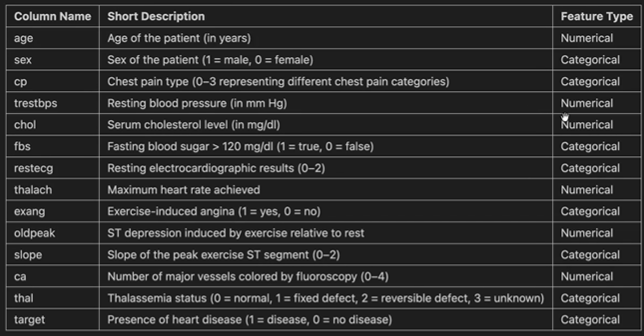

In [42]:
print(df['target'].value_counts())
print("-"*70)
print(df['target'].value_counts(normalize=True)*100)

target
1    526
0    499
Name: count, dtype: int64
----------------------------------------------------------------------
target
1   51.317
0   48.683
Name: proportion, dtype: float64


#### **4.Univariate, Bivariate, Multivariate Analysis**

In [40]:
num_cols=['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
cat_cols=["sex","cp","fbs","restecg","exang","slope","ca","thal","target"]
print("Numerical columns:", num_cols)
print("-"*70)
print("Categorical columns:", cat_cols)


Numerical columns: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
----------------------------------------------------------------------
Categorical columns: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal', 'target']


#### Univariate Analysis

In [43]:
df[num_cols].describe()

,age,trestbps,chol,thalach,oldpeak
count,1025.000,1025.000,1025.000,1025.000,1025.000
mean,54.434,131.612,246.000,149.114,1.072
std,9.072,17.517,51.593,23.006,1.175
min,29.000,94.000,126.000,71.000,0.000
25%,48.000,120.000,211.000,132.000,0.000
50%,56.000,130.000,240.000,152.000,0.800
75%,61.000,140.000,275.000,166.000,1.800
max,77.000,200.000,564.000,202.000,6.200


Numerical Features Analysis - Histplot

In [ ]:

for col in num_cols:
    plt.figure(figsize=(4,3))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()
    print(" ")

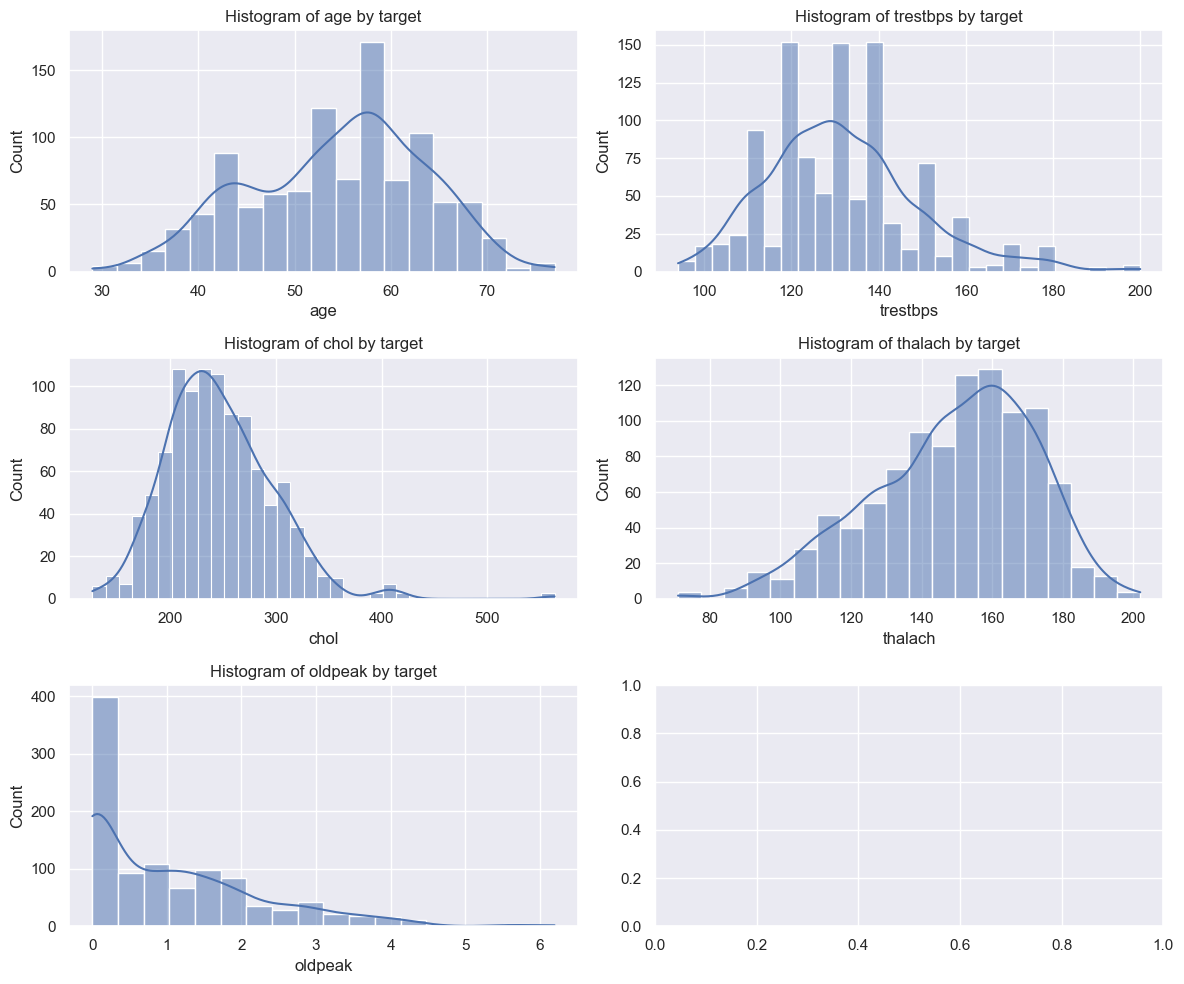

In [92]:
fig,axes=plt.subplots(3,2, figsize=(12,10))
axes=axes.flatten()
for i, col in enumerate(num_cols):
    sns.histplot(x=df[col], kde=True, ax=axes[i])
    axes[i].set_title(f"Histogram of {col} by target")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")
plt.tight_layout()
plt.show()
    

Categorical Feature Analysis - Countplot

In [ ]:
for col in cat_cols:
    plt.figure(figsize=(4,3))
    sns.countplot(x=df[col])
    plt.title(f"Count of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()
    print(" ")

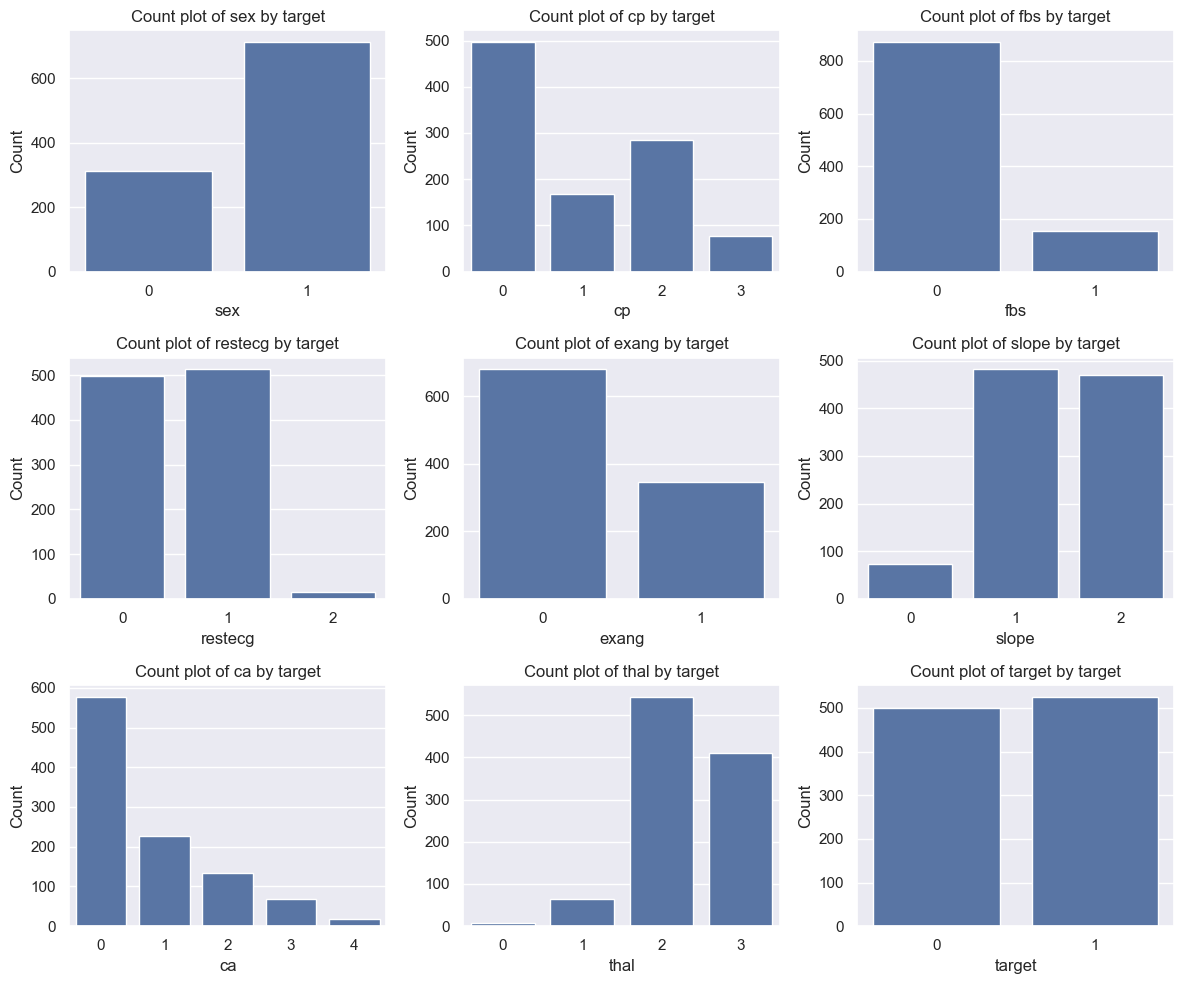

In [85]:
fig,axes=plt.subplots(3,3, figsize=(12,10))
axes=axes.flatten()
for i, col in enumerate(cat_cols):
    sns.countplot(x=df[col], ax=axes[i])
    axes[i].set_title(f"Count plot of {col} by target")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")
plt.tight_layout()
plt.show()
    

#### Bivariate Analysis

Numerical vs Numerical - ScatterPlot

In [ ]:
num_pairs=[("age", "trestbps"), 
           ("age", "chol"), 
           ("age", "thalach"), 
           ("age", "oldpeak"), 
           ("trestbps", "chol"),
           ("trestbps", "thalach"),
           ("trestbps", "oldpeak"), 
           ("chol", "thalach"), 
           ("chol", "oldpeak"), 
           ("thalach", "oldpeak")
    ]
for x,y in num_pairs:
    plt.figure(figsize=(4,3))
    sns.scatterplot(x=df[x], y=df[y])
    plt.title(f"Scatter plot of {x} vs {y}")
    plt.xlabel(x)
    plt.ylabel(y)
    plt.show()
    print(" ")

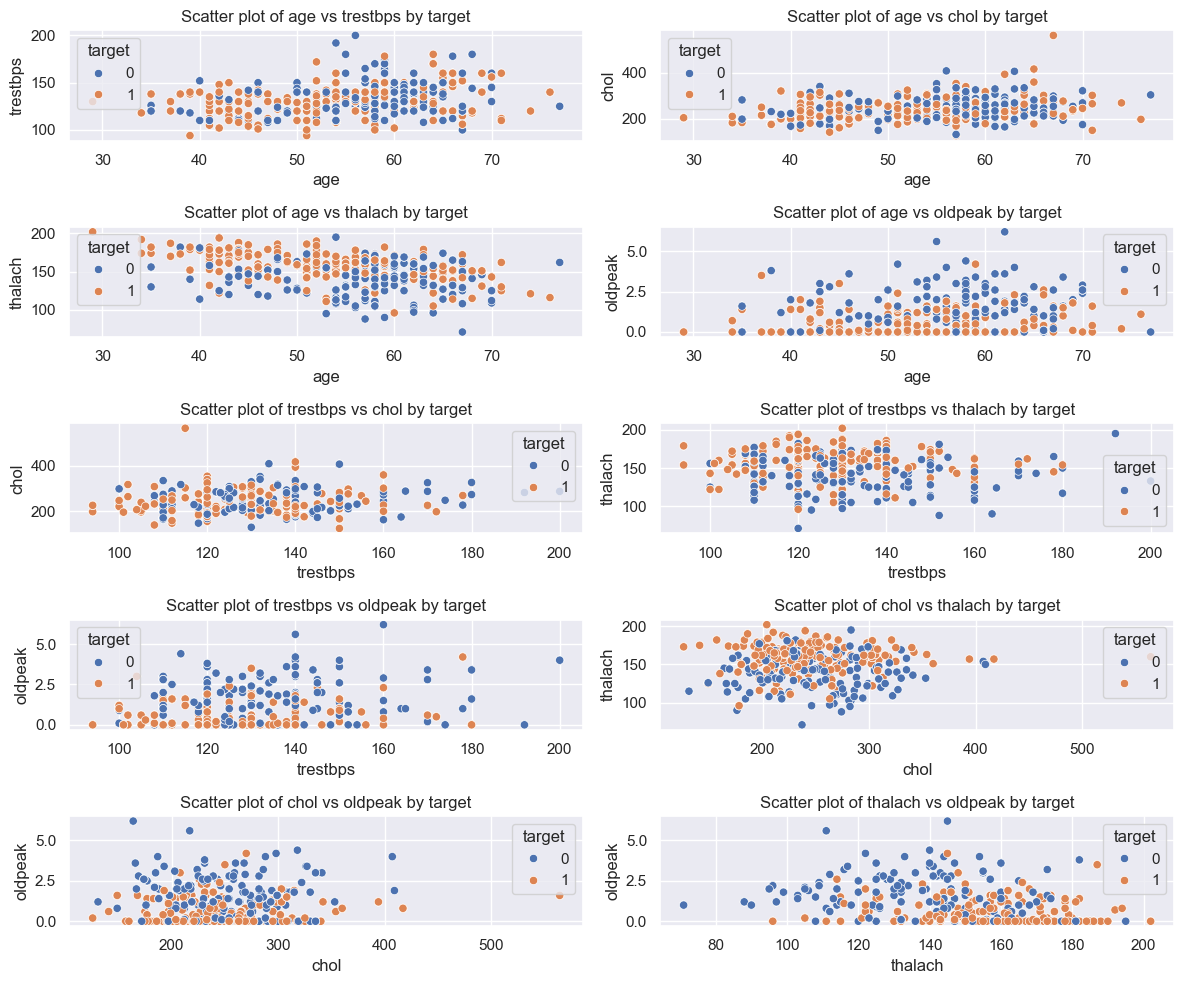

In [87]:
fig, axes = plt.subplots(5, 2, figsize=(12, 10))
axes = axes.flatten()
for i, col in enumerate(num_pairs):
    sns.scatterplot(x=df[col[0]], y=df[col[1]], hue=df['target'], ax=axes[i])
    axes[i].set_title(f"Scatter plot of {col[0]} vs {col[1]} by target")
    axes[i].set_xlabel(col[0])
    axes[i].set_ylabel(col[1])
plt.tight_layout()
plt.show()


Correlation matrix - only for Numerical cols

In [ ]:
df[num_cols].corr()
plt.figure(figsize=(6,5))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='Blues', fmt=".2f")
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

Numerical vs Categorical - Boxplot

In [ ]:
plt.figure(figsize=(6,5))
for col in num_cols:
    sns.boxplot(x=df['target'], y=df[col],label="0=No Disease, 1=Disease")
    plt.title(f"Box plot of {col} by target")
    plt.xlabel("Survived")
    plt.ylabel(col)
    plt.show()
    print(" ")

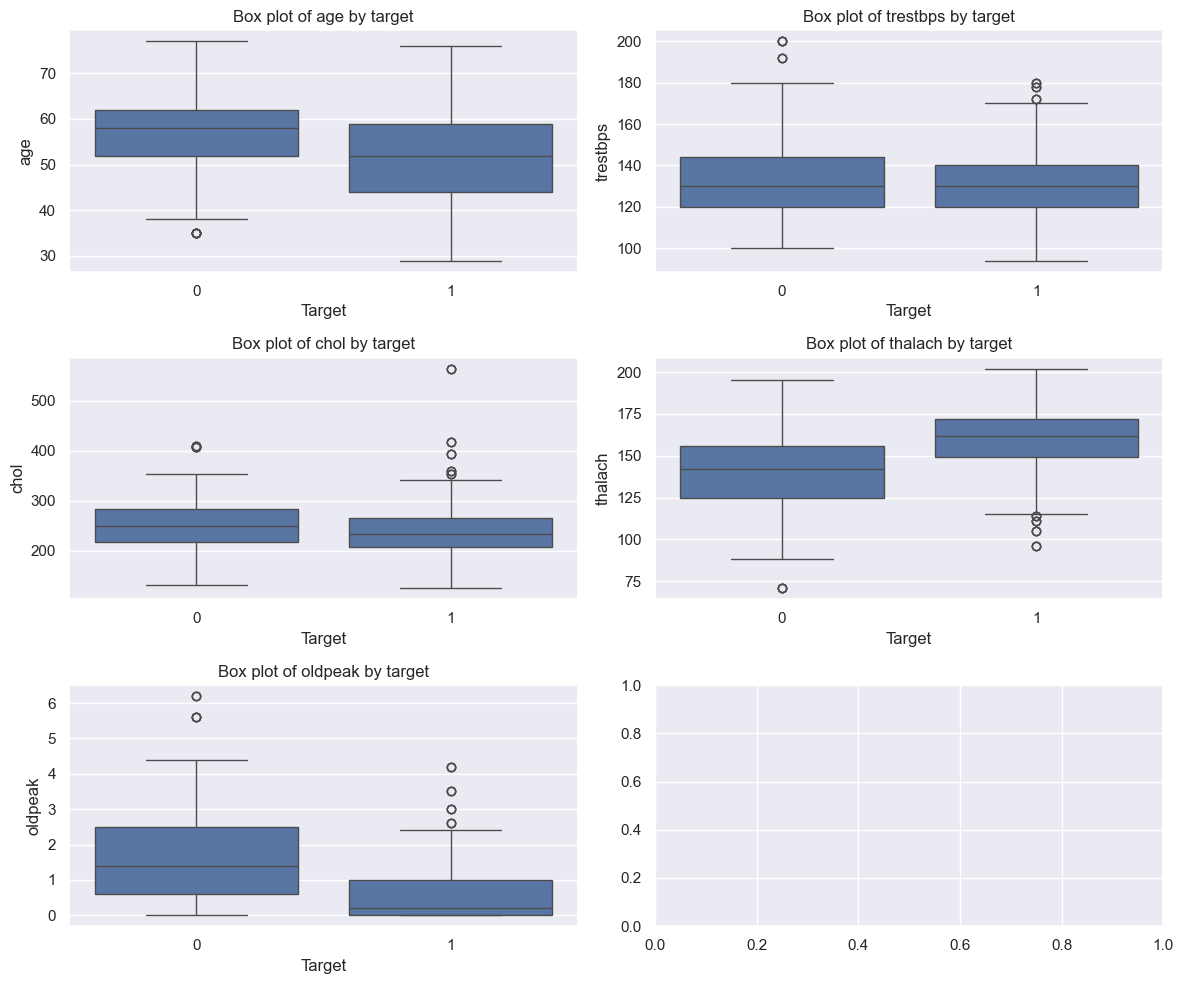

In [88]:
fig, axes = plt.subplots(3, 2, figsize=(12, 10))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.boxplot(x=df['target'], y=df[col], ax=axes[i])
    axes[i].set_title(f"Box plot of {col} by target")
    axes[i].set_xlabel("Target")
    axes[i].set_ylabel(col)
plt.tight_layout()
plt.show()

Grouped Statistics

In [58]:
#it grouped target column with the remaining columns
print(round(df[num_cols+["target"]].groupby("target").mean(),3))
print("-"*50)

          age  trestbps    chol  thalach  oldpeak
target                                           
0      56.569   134.106 251.293  139.130    1.600
1      52.409   129.245 240.979  158.586    0.570
--------------------------------------------------


Categorical vs Categorical - Count plot

In [59]:
print(cat_cols)

['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal', 'target']


In [ ]:
    
for col in cat_cols:
    plt.figure(figsize=(5,4))
    sns.countplot(x=df[col], hue=df["target"])
    plt.title(f"Count plot of {col} by target")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()
    print(" ")

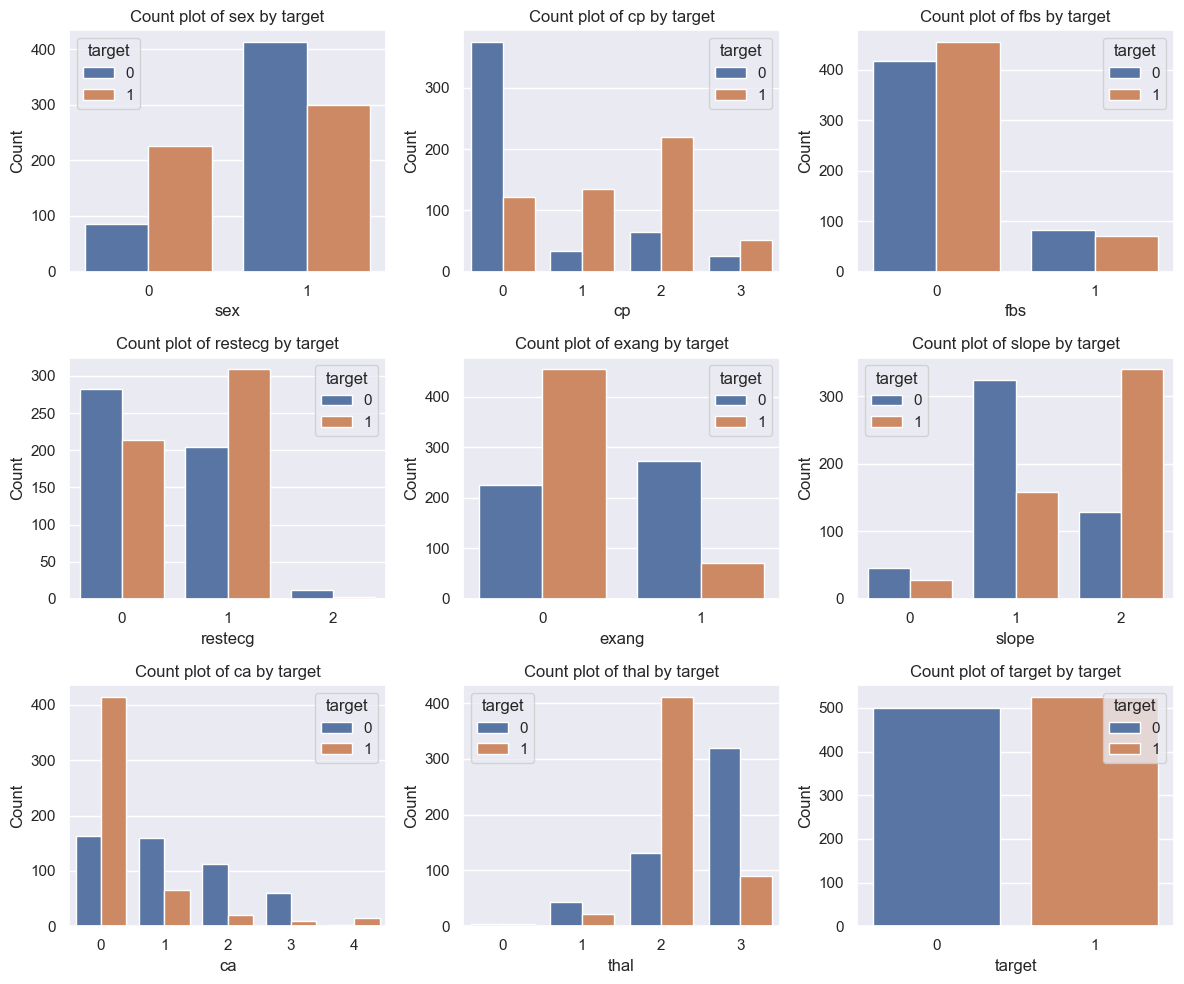

In [91]:
fig,axes=plt.subplots(3,3, figsize=(12,10))
axes=axes.flatten()
for i, col in enumerate(cat_cols):
    sns.countplot(x=df[col], hue=df["target"], ax=axes[i])
    axes[i].set_title(f"Count plot of {col} by target")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")
plt.tight_layout()
plt.show()

#### Multivariate Analysis

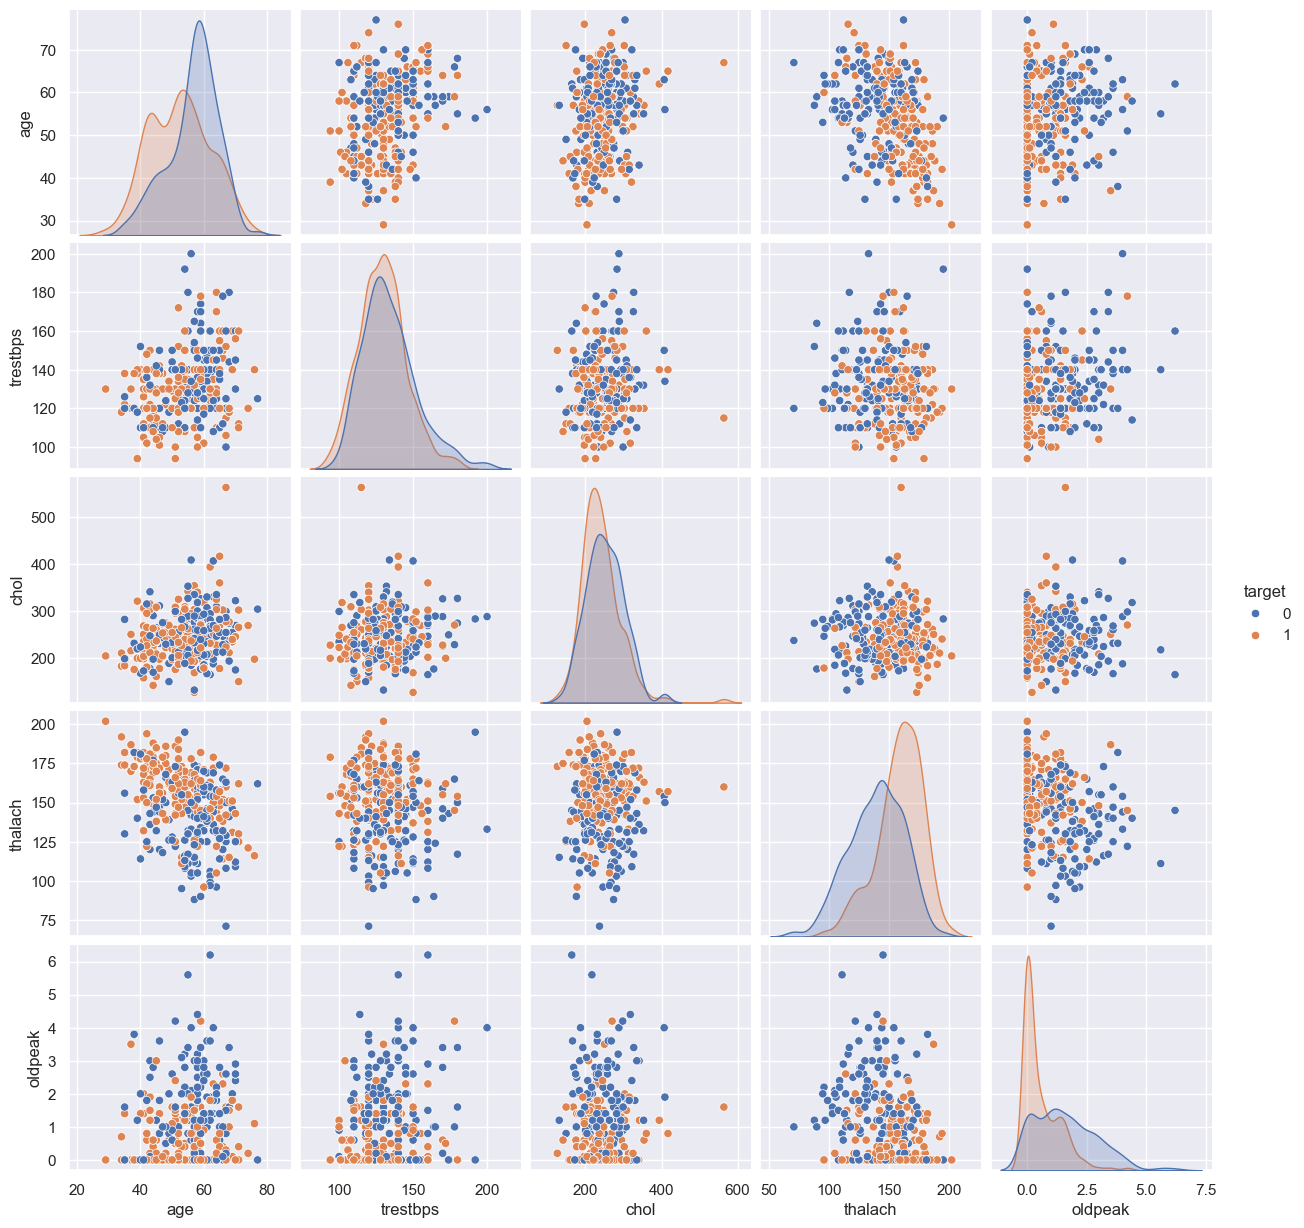

In [93]:
pair_plot=num_cols+["target"]
sns.pairplot(df[pair_plot], hue="target")
plt.show()

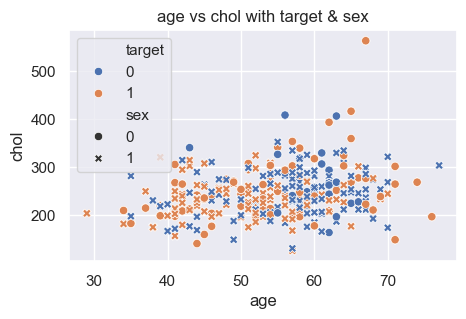

In [ ]:
#age vs fare with survival & sex
#**Interaction and sub-group pattern**
plt.figure(figsize=(5,3))
sns.scatterplot(data=df,x="age",y="chol",hue="target",style="sex")
plt.title("age vs chol with target & sex")
plt.show()

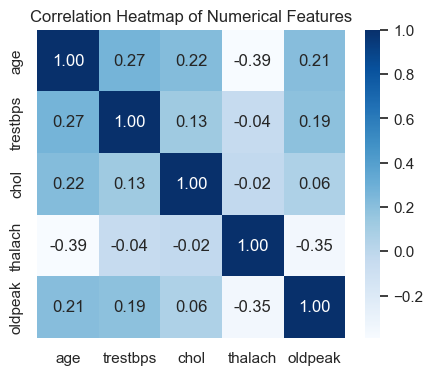

In [99]:
#HeatMap
plt.figure(figsize=(5,4))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='Blues', fmt=".2f", square=True)
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

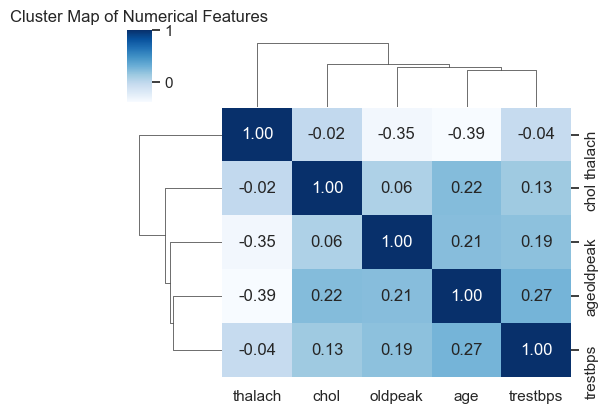

In [104]:
#Cluster Map
sns.clustermap(df[num_cols].corr(), annot=True, cmap='Blues', fmt=".2f",figsize=(5,4))
plt.title("Cluster Map of Numerical Features")
plt.show()

### **4.Preprocessing**

In [110]:
#separete x, y
x=df.drop(columns=[TARGET_COL])
y=df[TARGET_COL]

#row signature with similar rows
row_signature=pd.util.hash_pandas_object(x, index=False)
#print(row_signature)

In [113]:
gss= GroupShuffleSplit(test_size=0.2, n_splits=1, random_state=int(RANDOM_STATE))
train_idx, test_idx = next(gss.split(x, y, groups=row_signature))

x_train, x_test = x.iloc[train_idx], x.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print(x_train.shape, x_test.shape)

(817, 13) (208, 13)
